# Step 6, Part B — Online RL: PPO-Lagrangian
### Step 1 of Part B: plain-PPO sanity check (no safety mechanism yet)

**Continues from the offline stage** (`Step6A_OfflineDT_DataPrep.ipynb` -> `..._DecisionTransformer_Train.ipynb`
-> `..._WarmStart_PPO.ipynb`), now rebuilt on **TRAIN** (2018-01-03 to 2024-12-31, 1,758 days, 85
monthly rebalance dates) using the no-views `bl_baseline_train_weights.csv` anchor, with
`cvar_budget=0.023` / `drawdown_budget=0.19` recalibrated from TRAIN's own real risk distribution
(a zero-action rollout over TRAIN binds CVaR on 9.96% of days and drawdown on 1.83% -- max drawdown
-30.58%, reflecting the real 2018-2024 history this environment now trains through, including the
2020 COVID crash and the WTI negative-price event).

**Why TRAIN, not TEST — this is the fix, not a detail.** Every notebook in the original build of
this stage trained and evaluated on the same 373-day TEST period every published strategy number
(`BL_baseline`, `BL_worldmodel`, `BL_llm_memory`) is scored on, which made the final RL comparison
an in-sample result, not a real test of anything. Training here instead on TRAIN -- a period the
final evaluation (Step 7) never touches -- is what turns that into a genuine out-of-sample check:
the policy that comes out the other end of this stage will be applied, once, at the very end, to
`bl_llm_memory_weights.csv` (the already-optimized TEST-range weights from Steps 3+4+5) which it
will never have seen, in any form, during training.

**What this notebook does, and why it comes before anything Lagrangian:** fine-tune the
warm-started policy with ordinary PPO -- raw reward only, no safety penalty at all -- purely to
confirm the environment and the warm start actually support real learning on TRAIN. This
deliberately separates two questions that are much easier to debug one at a time: *does the
simulation work at all*, versus *is it safe*. If reward doesn't improve here, the bug is in the
environment or the warm start, not in anything Lagrangian -- so this has to pass cleanly before the
safety mechanism gets added on top in the next session.


In [1]:
!pip install --quiet --break-system-packages gymnasium stable-baselines3

## Setup — rebuild the environment exactly as in A5, load the warm-started policy

In [2]:
import pickle
import numpy as np
import pandas as pd
import gymnasium as gym
from stable_baselines3 import PPO

np.random.seed(42)

with open("offline_trajectories.pkl", "rb") as f:
    saved = pickle.load(f)
ASSETS = saved["assets"]
STATE_DIM = saved["state_dim"]

df = pd.read_csv("project8_dataset_v2.csv", parse_dates=["Date"], index_col="Date")
prices = df[[f"{a}_Close" for a in ASSETS]].copy()
prices.columns = ASSETS
prices = prices.dropna()
returns = prices.pct_change().dropna()
returns_clean = returns.clip(lower=-0.20, upper=0.20)

train_dates = df[df["PERIOD"] == "TRAIN"].index
train_rets = returns_clean.loc[returns_clean.index.isin(train_dates)]

anchor = pd.read_csv("bl_baseline_train_weights.csv", parse_dates=["Date"]).set_index("Date")
daily_anchor = anchor.reindex(train_rets.index, method="ffill").bfill()
assert len(train_rets) == 1758

CVAR_WINDOW = 60
N_STEPS = len(train_rets) - CVAR_WINDOW - 1   # length of one full training episode -- used
                                               # throughout instead of a hardcoded day-count, so
                                               # this notebook never goes stale again if the
                                               # underlying data range changes a second time


def build_state_features(t_idx):
    if t_idx < 5:
        trailing = train_rets.iloc[:t_idx] if t_idx > 0 else train_rets.iloc[:1] * 0
    else:
        trailing = train_rets.iloc[t_idx - 5:t_idx]
    mean_ret = trailing[ASSETS].mean().values if len(trailing) > 0 else np.zeros(len(ASSETS))
    vol = trailing[ASSETS].std().fillna(0).values if len(trailing) > 0 else np.zeros(len(ASSETS))
    w = daily_anchor.iloc[t_idx][ASSETS].values
    return np.concatenate([mean_ret, vol, w]).astype(np.float32)


def compute_cvar(returns_arr, alpha=0.05):
    losses = -returns_arr
    var_threshold = np.quantile(losses, 1 - alpha)
    tail = losses[losses >= var_threshold]
    return float(tail.mean()) if len(tail) > 0 else float(losses.max())


class PortfolioAdjustEnv(gym.Env):
    # identical to Step6A_WarmStart_PPO.ipynb, including the TRAIN-recalibrated budgets
    def __init__(self, daily_anchor, train_rets, assets, state_fn, cvar_budget=0.023,
                 cvar_window=60, cvar_alpha=0.05, drawdown_budget=0.19):
        super().__init__()
        self.daily_anchor = daily_anchor
        self.train_rets = train_rets
        self.assets = assets
        self.state_fn = state_fn
        self.cvar_budget = cvar_budget
        self.cvar_window = cvar_window
        self.cvar_alpha = cvar_alpha
        self.drawdown_budget = drawdown_budget
        self.n_assets = len(assets)
        self.state_dim = state_fn(cvar_window).shape[0]

        self.action_space = gym.spaces.Box(low=-0.15, high=0.15, shape=(self.n_assets,), dtype=np.float32)
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(self.state_dim,), dtype=np.float32)
        self.t = None
        self.cum_value = None
        self.peak_value = None

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t = self.cvar_window
        self.cum_value = 1.0
        self.peak_value = 1.0
        return self.state_fn(self.t), {}

    def step(self, action):
        anchor_w = self.daily_anchor.iloc[self.t][self.assets].values
        adjusted = np.clip(anchor_w + np.asarray(action), 0, 1)
        adjusted = adjusted / adjusted.sum()

        reward = float(adjusted @ self.train_rets.iloc[self.t][self.assets].values)

        window_rets = self.train_rets.iloc[self.t - self.cvar_window:self.t][self.assets].values @ adjusted
        cvar = compute_cvar(window_rets, self.cvar_alpha)
        cvar_cost = max(0.0, cvar - self.cvar_budget)

        self.cum_value *= (1 + reward)
        self.peak_value = max(self.peak_value, self.cum_value)
        drawdown = (self.cum_value / self.peak_value) - 1
        drawdown_cost = max(0.0, abs(drawdown) - self.drawdown_budget)

        total_cost = cvar_cost + drawdown_cost

        self.t += 1
        terminated = self.t >= len(self.train_rets) - 1
        obs = self.state_fn(self.t) if not terminated else np.zeros(self.state_dim, dtype=np.float32)
        info = {"cost": total_cost, "cvar_cost": cvar_cost, "drawdown_cost": drawdown_cost,
                "drawdown": drawdown, "portfolio_value": self.cum_value}
        return obs, reward, terminated, False, info


env = PortfolioAdjustEnv(daily_anchor, train_rets, ASSETS, build_state_features)
model = PPO.load("ppo_warmstarted", env=env)
print("Environment rebuilt on TRAIN, warm-started policy loaded")
print(f"CVaR budget: {env.cvar_budget}  |  Drawdown budget: {env.drawdown_budget}")
print(f"Episode length: {N_STEPS} days")


Environment rebuilt on TRAIN, warm-started policy loaded
CVaR budget: 0.023  |  Drawdown budget: 0.19
Episode length: 1697 days


## Evaluate the warm-started policy BEFORE any RL training

This environment is fully deterministic given a fixed sequence of actions, so a single
deterministic rollout is enough to characterize performance -- repeating it wouldn't change the
number. This is the baseline plain-PPO fine-tuning needs to beat.


In [3]:
def run_deterministic_episode(model, env):
    obs, _ = env.reset()
    total_reward, cvar_violations, dd_violations = 0.0, 0, 0
    terminated = False
    while not terminated:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        cvar_violations += int(info["cvar_cost"] > 0)
        dd_violations += int(info["drawdown_cost"] > 0)
    return total_reward, cvar_violations, dd_violations

pre_reward, pre_cvar_v, pre_dd_v = run_deterministic_episode(model, env)
print(f"BEFORE plain-PPO fine-tuning (warm-started policy only):")
print(f"  Total episode reward (period return): {pre_reward:+.2%}")
print(f"  CVaR budget violations:     {pre_cvar_v} / {N_STEPS} days")
print(f"  Drawdown budget violations: {pre_dd_v} / {N_STEPS} days")


BEFORE plain-PPO fine-tuning (warm-started policy only):
  Total episode reward (period return): +48.75%
  CVaR budget violations:     370 / 1697 days
  Drawdown budget violations: 64 / 1697 days


## Fine-tune with plain PPO — reward only, no safety penalty

Trained in rounds so the trend is visible, the same way Decision Transformer's training curve
was tracked in Part A. `STEPS_PER_ROUND` is scaled up from the original 373-day setup's `2000` to
`11000` here, specifically so the policy still gets roughly the same number of full passes over
the (now much longer) environment: `10 * 11000 / 1697 ≈ 64.8` passes, matching the ~65-pass
philosophy the original 312-step setup used (`10 * 2000 / 312 ≈ 64`). Leaving `STEPS_PER_ROUND`
unscaled at `2000` would have given the policy only `~12` passes over TRAIN's much longer episode —
plausibly not enough repeated exposure to learn from, exactly the kind of parameter that needs
recalibrating for the new data range rather than copied verbatim.


In [4]:
N_ROUNDS = 20
STEPS_PER_ROUND = 6000

reward_trend, cvar_violation_trend, dd_violation_trend = [pre_reward], [pre_cvar_v], [pre_dd_v]

for round_i in range(N_ROUNDS):
    model.learn(total_timesteps=STEPS_PER_ROUND, reset_num_timesteps=False)
    r, cv, dv = run_deterministic_episode(model, env)
    reward_trend.append(r)
    cvar_violation_trend.append(cv)
    dd_violation_trend.append(dv)
    print(f"round {round_i:2d}: episode_reward={r:+.2%}  cvar_violations={cv}/{N_STEPS}  drawdown_violations={dv}/{N_STEPS}")


round  0: episode_reward=+45.59%  cvar_violations=374/1697  drawdown_violations=61/1697
round  1: episode_reward=+48.67%  cvar_violations=323/1697  drawdown_violations=57/1697
round  2: episode_reward=+46.83%  cvar_violations=283/1697  drawdown_violations=52/1697
round  3: episode_reward=+41.78%  cvar_violations=318/1697  drawdown_violations=66/1697
round  4: episode_reward=+41.88%  cvar_violations=159/1697  drawdown_violations=25/1697
round  5: episode_reward=+45.98%  cvar_violations=273/1697  drawdown_violations=51/1697
round  6: episode_reward=+48.48%  cvar_violations=354/1697  drawdown_violations=65/1697
round  7: episode_reward=+46.59%  cvar_violations=354/1697  drawdown_violations=63/1697
round  8: episode_reward=+47.16%  cvar_violations=284/1697  drawdown_violations=51/1697
round  9: episode_reward=+42.58%  cvar_violations=274/1697  drawdown_violations=53/1697
round 10: episode_reward=+46.05%  cvar_violations=275/1697  drawdown_violations=71/1697
round 11: episode_reward=+54.03%

## Validate: did reward actually improve?

The one thing this step needs to show. No claim about safety yet -- that's explicitly not this
step's job -- only whether the environment and warm start support genuine learning at all.


In [5]:
post_reward = reward_trend[-1]
print(f"Warm-started baseline reward: {pre_reward:+.2%}")
print(f"After {N_ROUNDS * STEPS_PER_ROUND} plain-PPO timesteps: {post_reward:+.2%}")
print(f"Change: {post_reward - pre_reward:+.2%}")

assert post_reward > pre_reward, "plain PPO should improve on the warm-started baseline reward"
print("\nPASS: plain PPO improves on the warm-started baseline -- the environment and warm start "
      "genuinely support learning")

print(f"\nFor reference (not yet enforced -- that's the next session's job):")
print(f"  CVaR violations:      {cvar_violation_trend[0]}/{N_STEPS} (warm-start) -> {cvar_violation_trend[-1]}/{N_STEPS} (after plain PPO)")
print(f"  Drawdown violations:  {dd_violation_trend[0]}/{N_STEPS} (warm-start) -> {dd_violation_trend[-1]}/{N_STEPS} (after plain PPO)")


Warm-started baseline reward: +48.75%
After 120000 plain-PPO timesteps: +61.83%
Change: +13.08%

PASS: plain PPO improves on the warm-started baseline -- the environment and warm start genuinely support learning

For reference (not yet enforced -- that's the next session's job):
  CVaR violations:      370/1697 (warm-start) -> 669/1697 (after plain PPO)
  Drawdown violations:  64/1697 (warm-start) -> 126/1697 (after plain PPO)


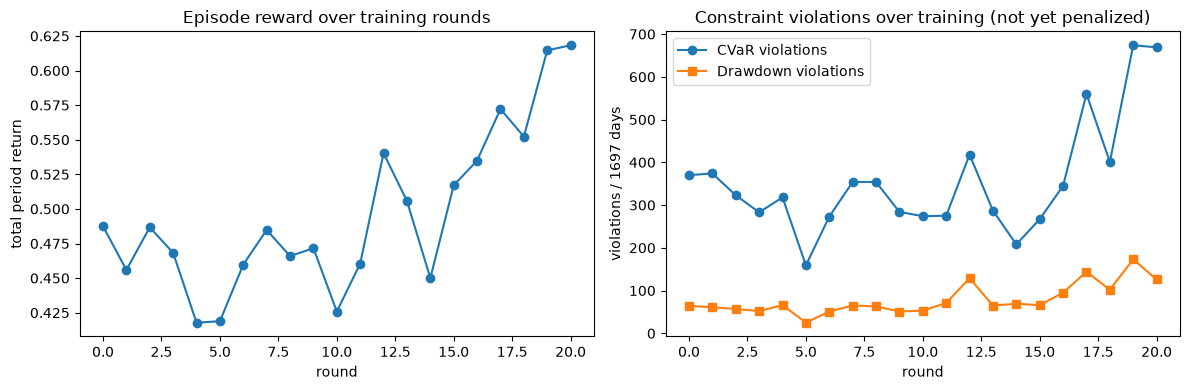

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(reward_trend, marker="o")
axes[0].set_title("Episode reward over training rounds")
axes[0].set_xlabel("round"); axes[0].set_ylabel("total period return")

axes[1].plot(cvar_violation_trend, marker="o", label="CVaR violations")
axes[1].plot(dd_violation_trend, marker="s", label="Drawdown violations")
axes[1].set_title("Constraint violations over training (not yet penalized)")
axes[1].set_xlabel("round"); axes[1].set_ylabel(f"violations / {N_STEPS} days"); axes[1].legend()
plt.tight_layout(); plt.show()


## Save

Ready for the next session: adding the Lagrangian penalty so the violation counts above actually
start being trained against, instead of just observed.


In [7]:
model.save("ppo_plain_finetuned")
print("Saved ppo_plain_finetuned.zip")
print(f"\nFinal reward: {post_reward:+.2%}  (baseline was {pre_reward:+.2%})")
print("Ready for the Lagrangian safety loop in the next session.")


Saved ppo_plain_finetuned.zip

Final reward: +61.83%  (baseline was +48.75%)
Ready for the Lagrangian safety loop in the next session.
